## Data Loading & Initialization
This step initializes the analysis environment by importing core data manipulation and visualization libraries, then loading the engineered dataset.
* **Source File:** titanic_cleaned.csv
* **Storage Location:** Located within the local project structure under the ../data/processed/ directory, signifying that preliminary data cleaning and preprocessing stages are complete.
* **Data Pipeline:** Loading from the processed directory ensures that missing values (like missing age values) are already handled, and feature engineering steps are locked in before plotting begins.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv('../data/processed/titanic_cleaned.csv')

## Passenger Class vs. Survival Rate
This visualization analyzes how a passenger's socio economic status (Ticket Class) impacted their likelihood of survival.
* **X-Axis (Pclass):** The passenger class (1st, 2nd, or 3rd).
* **Y-Axis (Survival Rate):** The percentage of passengers within that specific class who survived.

Survival rate dropped sharply with passenger class, falling from **63% in 1st class** down to **47% in 2nd class**, and bottoming out at just **24% for passengers in 3rd class**.

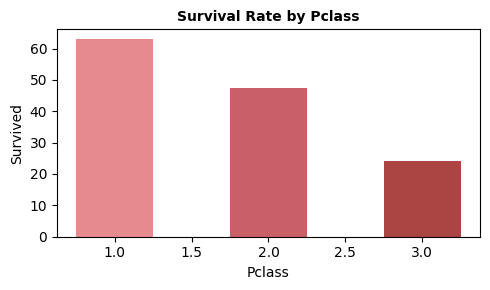

In [48]:
ab=df.groupby('Pclass')['Survived'].mean()*100
fig , ax =plt.subplots(figsize=(5,3))
ax.bar(ab.index,ab.values,color=['#e68a8d','#c96068','#ab4543'], width=0.5)
ax.set_title('Survival Rate by Pclass', fontweight='bold', fontsize=10)
ax.set_xlabel('Pclass')
ax.set_ylabel('Survived')
plt.tight_layout()
plt.show()

## Gender vs. Survival Rate
This visualization tracks the survival probability between male and female passengers, illustrating the impact of the historic "women and children first" evacuation protocol.
* **X-Axis (Sex):** Passenger gender (Female / Male).
* **Y-Axis (Survival Rate (%))**: The percentage of passengers within that gender group who survived.

There is a massive gender disparity in survival outcomes; **74% of female passengers** survived the disaster, compared to a meager **19% survival rate among male** passengers.

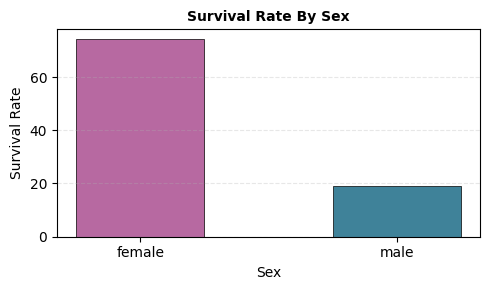

In [ ]:
cd=df.groupby('Sex')['Survived'].mean()*100
fig , ax=plt.subplots(figsize=(5,3))
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.bar(cd.index, cd.values, color=["#b769a1", "#3F8299"], edgecolor='black', linewidth=0.5, width=0.5)
ax.set_title('Survival Rate By Sex', fontweight='bold', fontsize=10)
ax.set_xlabel('Sex')
ax.set_ylabel('Survival Rate')
plt.tight_layout()
plt.show()

## Comparative Analysis: Socio Economic Status & Gender vs. Survival
This side by side subplot layout compares the two most significant categorical drivers of survival on the Titanic: ticket class and gender.
* **Left Plot (Passenger Class):** Visually highlights the steady, steep decline in survival as ticket tiers decrease, dropping from 63% (1st Class) to 24% (3rd Class).
* **Right Plot (Gender):** Highlights the crushing gap between safety outcomes, demonstrating a 55% absolute difference in survival probability favoring female passengers (74% vs 19%).

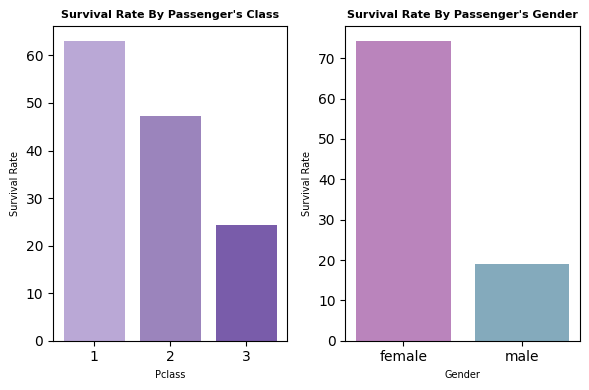

In [42]:
a=df.groupby('Pclass')['Survived'].mean()*100
b=df.groupby('Sex')['Survived'].mean()*100
fig, axes =plt.subplots(1,2,figsize=(6,4))
axes[0].bar(a.index,a.values, color=['#baa8d6', '#9b84bc', '#795caa'])
axes[0].set_title("Survival Rate By Passenger's Class", fontsize=8, fontweight='bold')
axes[0].set_xlabel('Pclass',fontsize=7)
axes[0].set_ylabel('Survival Rate',fontsize=7)
axes[1].bar(b.index,b.values, color=['#ba84bc', '#84aabc'])
axes[1].set_title("Survival Rate By Passenger's Gender",fontsize=8, fontweight='bold')
axes[1].set_xlabel('Gender',fontsize=7)
axes[1].set_ylabel('Survival Rate',fontsize=7)
plt.tight_layout()

## Age Distribution: Survived vs. Deceased
This visualization uses overlapping histograms to compare the age distributions of passengers who survived against those who did not, helping to pinpoint which age groups were most vulnerable.
* **X-Axis (Age_Filled):** Passenger age, grouped into 10 consistent intervals (bins) spanning from infants to elderly travelers.
* **Y-Axis (Frequency/Count):** The raw number of passengers falling within each specific age bracket.

The distribution reveals a protective bias toward youth; children under the age of 5 experienced a high survival rate of over 60%. Conversely, the vast majority of casualties were heavily concentrated in the young adult demographic between 18 and 35 years old, where the number of deceased passengers sharply outpaced the survivors in every single bin.

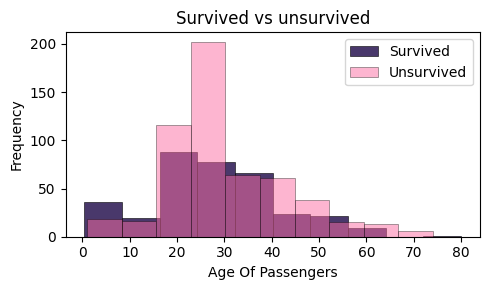

In [68]:
fig , ax= plt.subplots(figsize=(5,3))
ax.hist(df[df['Survived']==1]['Age_Filled'], bins=10, alpha=0.8, label='Survived', edgecolor='black', linewidth=0.5, color='#1c0646')
ax.hist(df[df['Survived']==0]['Age_Filled'], bins=10, alpha=0.5, label='Unsurvived',edgecolor='black', linewidth=0.5, color='#fd6ca3')
ax.set_xlabel('Age Of Passengers')
ax.set_ylabel('Frequency')
ax.set_title('Survived vs unsurvived')
ax.legend()
plt.tight_layout()
plt.show()

## Family Size Bracket vs. Survival Rate
This visualization tracks how traveling with family members affected a passenger's chances of survival, demonstrating that both isolation and excessively large group sizes lowered safety outcomes.
* **X-Axis (Family Band):** The categorized family size (typically segmented into groups like Alone, Small Family, and Large Family).
* **Y-Axis (Survival Rate):** The percentage of passengers within each bracket who survived.

Passangers traveling in Small Families (2–4 members) enjoyed the highest survival rate at roughly 58%, benefiting from mutual assistance without losing mobility. In contrast, those traveling Alone dropped to a 30% survival rate, while Large Families (5+ members) saw their survival chances crater to under 15% due to the extreme difficulty of coordinating an escape together.

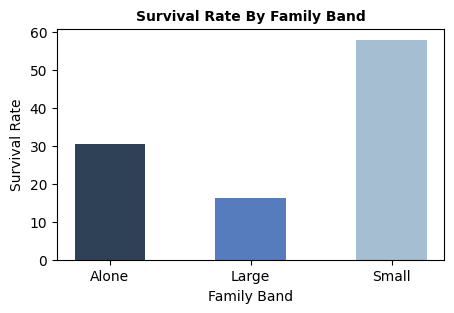

In [74]:
x=df.groupby('FamilyBand')['Survived'].mean()*100
fig , ax=plt.subplots(figsize=(5,3))
ax.bar(x.index,x.values,color=['#2f4156','#567cbd',"#a6bed1"], width=0.5)
ax.set_title('Survival Rate By Family Band', fontweight='bold', fontsize=10)
ax.set_xlabel('Family Band')
ax.set_ylabel('Survival Rate')
plt.show()